In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_importance

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('vitals_full.csv')
df.head()

,patient_id,record_id,day_offset,age,sex,systolic,diastolic,sugar,weight,bmi,note,bp_severity,sugar_severity,bmi_severity,overall_risk,risk_group,split
0,P00000,P00000-000,4,59,M,101.9,73.4,109.2,84.7,26.1,After medication,normal,borderline,borderline,moderate,prediabetic,train
1,P00000,P00000-001,45,59,M,106.4,63.4,NaN,84.2,25.9,NaN,normal,NaN,borderline,low,prediabetic,train
2,P00000,P00000-002,63,59,M,101.1,71.8,NaN,NaN,NaN,After a brisk walk,normal,NaN,NaN,none,prediabetic,train
3,P00000,P00000-003,73,59,M,90.1,68.9,113.5,84.7,26.1,Post-meal reading,normal,borderline,borderline,moderate,prediabetic,train
4,P00000,P00000-004,77,59,M,99.3,75.8,114.7,84.8,26.1,Post-meal reading,normal,borderline,borderline,moderate,prediabetic,train


In [8]:
df.shape

(17497, 17)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17497 entries, 0 to 17496
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      17497 non-null  object 
 1   record_id       17497 non-null  object 
 2   day_offset      17497 non-null  int64  
 3   age             17497 non-null  int64  
 4   sex             17497 non-null  object 
 5   systolic        16635 non-null  float64
 6   diastolic       16635 non-null  float64
 7   sugar           11297 non-null  float64
 8   weight          14923 non-null  float64
 9   bmi             14923 non-null  float64
 10  note            10436 non-null  object 
 11  bp_severity     16635 non-null  object 
 12  sugar_severity  11297 non-null  object 
 13  bmi_severity    14923 non-null  object 
 14  overall_risk    17456 non-null  object 
 15  risk_group      17497 non-null  object 
 16  split           17497 non-null  object 
dtypes: float64(5), int64(2), object

In [10]:
df.isnull().sum()

,0
patient_id,0
record_id,0
day_offset,0
age,0
sex,0
systolic,862
diastolic,862
sugar,6200
weight,2574
bmi,2574


In [11]:
df = df.dropna(subset=['overall_risk'])
df.isnull().sum()

,0
patient_id,0
record_id,0
day_offset,0
age,0
sex,0
systolic,821
diastolic,821
sugar,6159
weight,2533
bmi,2533


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["sex"] = df["sex"].map({
    "M":1,
    "F":0
})

df.head()

,patient_id,record_id,day_offset,age,sex,systolic,diastolic,sugar,weight,bmi,note,bp_severity,sugar_severity,bmi_severity,overall_risk,risk_group,split
0,P00000,P00000-000,4,59,1,101.9,73.4,109.2,84.7,26.1,After medication,normal,borderline,borderline,moderate,prediabetic,train
1,P00000,P00000-001,45,59,1,106.4,63.4,NaN,84.2,25.9,NaN,normal,NaN,borderline,low,prediabetic,train
2,P00000,P00000-002,63,59,1,101.1,71.8,NaN,NaN,NaN,After a brisk walk,normal,NaN,NaN,none,prediabetic,train
3,P00000,P00000-003,73,59,1,90.1,68.9,113.5,84.7,26.1,Post-meal reading,normal,borderline,borderline,moderate,prediabetic,train
4,P00000,P00000-004,77,59,1,99.3,75.8,114.7,84.8,26.1,Post-meal reading,normal,borderline,borderline,moderate,prediabetic,train


In [14]:
X = df.iloc[:, 3:10]
X.head()

,age,sex,systolic,diastolic,sugar,weight,bmi
0,59,1,101.9,73.4,109.2,84.7,26.1
1,59,1,106.4,63.4,NaN,84.2,25.9
2,59,1,101.1,71.8,NaN,NaN,NaN
3,59,1,90.1,68.9,113.5,84.7,26.1
4,59,1,99.3,75.8,114.7,84.8,26.1


In [15]:
y = df["overall_risk"]
y.head()

,overall_risk
0,moderate
1,low
2,none
3,moderate
4,moderate


In [16]:
y.value_counts()

,count
overall_risk,
high,5311
low,4178
moderate,4135
none,3832


In [17]:
y.dropna(inplace=True)
print(y.isnull().sum())

0


In [18]:
X.fillna(df.median(numeric_only=True), inplace=True)
X.isnull().sum()

,0
age,0
sex,0
systolic,0
diastolic,0
sugar,0
weight,0
bmi,0


In [19]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
print(y_encoded)
print(y)
print(label_encoder.classes_)

[2 1 3 ... 1 1 3]
0        moderate
1             low
2            none
3        moderate
4        moderate
           ...   
17492         low
17493         low
17494         low
17495         low
17496        none
Name: overall_risk, Length: 17456, dtype: object
['high' 'low' 'moderate' 'none']


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print(X_train.head())

Training data shape: (13964, 7)
Testing data shape: (3492, 7)
       age  sex  systolic  diastolic  sugar  weight   bmi
5478    71    1     129.7       83.0  126.0    75.3  28.6
11954   20    1     127.7       78.2   99.6    73.5  24.1
5271    64    1     111.6       71.8   96.9    71.7  23.1
9962    48    1     146.2       84.0   96.9    77.3  27.6
14455   49    1     118.4       66.4   96.9    75.4  23.7


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)

Scaled training data shape: (13964, 7)


***MODEL TRAINED***

In [22]:
model = xgb.XGBClassifier(
        n_estimators= 400,
        max_depth= 4,
        learning_rate= 0.05,
        objective="multi:softprob",
        num_class= 4,
        eval_metric="mlogloss",
        early_stopping_rounds= 30,
        random_state= 42,
        n_jobs=-1,
    )
model.fit(
        X_train_scaled, y_train,
        eval_set=[(X_test_scaled, y_test)],
        verbose=False,
    )
model.save_model("healthmate_model.json")

print("Model trained successfully")

Model trained successfully


In [23]:
xgb_preds = model.predict(X_test_scaled)
xgb_preds

array([3, 2, 1, ..., 3, 2, 3])

In [24]:
accuracy = accuracy_score(y_test, xgb_preds)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.99


In [25]:
print(classification_report(y_test, xgb_preds, zero_division=0))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1065
           1       0.98      0.99      0.98       834
           2       1.00      0.98      0.99       822
           3       0.99      0.99      0.99       771

    accuracy                           0.99      3492
   macro avg       0.99      0.99      0.99      3492
weighted avg       0.99      0.99      0.99      3492



In [26]:
print("Train Score:", model.score(X_train_scaled, y_train))
print("Test Score:", model.score(X_test_scaled, y_test))

Train Score: 0.9968490403895732
Test Score: 0.9882588774341352


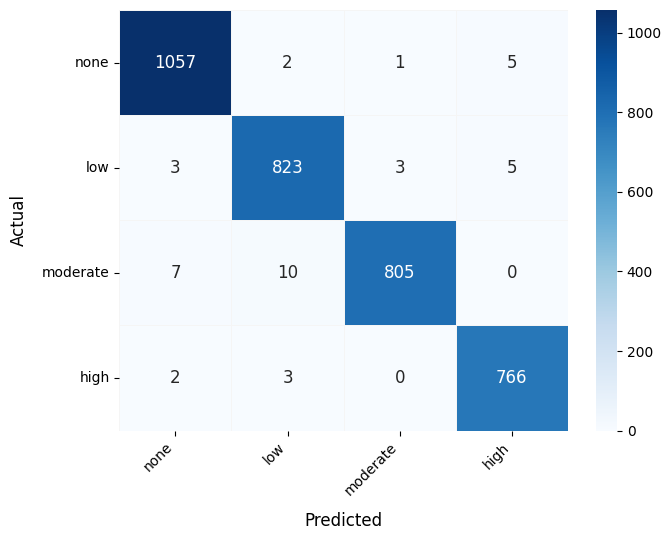

In [27]:
cm = confusion_matrix(y_test, xgb_preds)
labels = ['none', 'low', 'moderate', 'high']

plt.figure(figsize=(7, 5.5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels,
    cbar=True,
    annot_kws={"size": 12},
    linewidths=0.5,
    linecolor='whitesmoke'
)

# 4. Match the exact axis labels and rotations
plt.xlabel('Predicted', fontsize=12, labelpad=10)
plt.ylabel('Actual', fontsize=12, labelpad=10)

# Rotate x-axis labels to look exactly like the image
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Adjust layout so labels aren't cut off
plt.tight_layout()
plt.show()


In [28]:
new_patient = pd.DataFrame({
    'age': [52],
    'sex': [1],
    'systolic': [148],
    'diastolic': [94],
    'sugar': [138],
    'weight': [70],
    'bmi': [30.5]
})

# Scale using the SAME scaler
new_patient_scaled = scaler.transform(new_patient)

# Predict
prediction = model.predict(new_patient_scaled)

prediction
# Convert number back to text label
predicted_risk = label_encoder.inverse_transform(prediction)

print("Predicted overall risk:", predicted_risk[0])

Predicted overall risk: high


[0.00326053 0.00383288 0.27033955 0.24143693 0.21680364 0.00689824
 0.2574282 ]


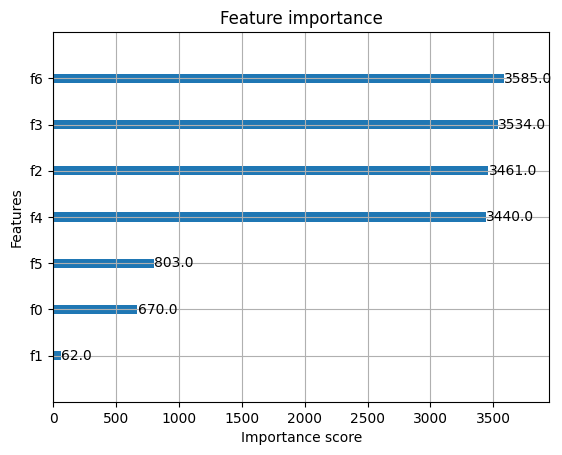

In [29]:
print(model.feature_importances_)
plot_importance(model)
plt.show()

In [30]:
import pickle

with open("healthmate_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("models saved")

models saved


In [31]:
pickle.dump(
    {
        "model": model,
        "scaler": scaler,
        "encoder": label_encoder
    },
    open("healthmate_pipeline.pkl","wb")
)

with open("healthmate_model.pkl", "rb") as f:
    model = pickle.load(f)

prediction = model.predict(new_patient_scaled)

prediction
# Convert number back to text label
predicted_risk = label_encoder.inverse_transform(prediction)

print("Predicted overall risk:", predicted_risk[0])

Predicted overall risk: high
